# Netflixの作品傾向を分析
- [x] 一番短い映画と長い映画
- [x] 映画とドラマの割合
- [x] 年ごとの作品数の推移
- [x] 国別の作品数ランキング
- [x] 国ごとの特徴
- [x] ジャンル数ランキング
- [x] 年齢制限の分布
- [x] Netflixはどんな作品を増やしてきたか（時系列分析）
- [x] よく一緒に出演する俳優・監督
- [x] 文章分析（NLP)
- [x] レコメンドシステム
  「〇〇を見た人にはこれがおすすめ」という簡単な推薦システム

# データ読み込み

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("./netflix_processing.csv")
df.head()

,Unnamed: 0,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,add_year,add_month
0,0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [3]:
df.shape

(8807, 15)

In [4]:
df.describe()

,Unnamed: 0,release_year,add_year,add_month
count,8807.000000,8807.000000,8709.000000,8709.000000
mean,4403.000000,2014.180198,2018.887932,6.653347
std,2542.506244,8.819312,1.567961,3.431434
min,0.000000,1925.000000,2008.000000,1.000000
25%,2201.500000,2013.000000,2018.000000,4.000000
50%,4403.000000,2017.000000,2019.000000,7.000000
75%,6604.500000,2019.000000,2020.000000,10.000000
max,8806.000000,2021.000000,2021.000000,12.000000


# データ修正

In [5]:
# ratingにdurationの66min, 74min, 84minが入っていたため、durationに移動
mask = df["rating"].str.contains("min|Season", na=False)
df.loc[mask, ["rating", "duration"]] = df.loc[mask, ["duration", "rating"]].values

In [6]:
# Unnamed列削除
df = df.drop(df.columns[0], axis=1)

In [7]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,add_year,add_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [8]:
df.shape

(8807, 14)

# データ分析

## 映画・TV（type）

#### 映画とドラマの割合

In [9]:
df["type"].value_counts(normalize=True)

type
Movie      0.696151
TV Show    0.303849
Name: proportion, dtype: float64

#### 一番短い映画と長い映画

In [10]:
movies = df[df["type"]=="Movie"]
movies["duration_min_max"] = movies["duration"].str.extract(r"(\d+)").astype(float)

In [11]:
shortest_movie = movies.sort_values("duration_min_max").head(1)
print(shortest_movie)

     show_id   type   title                           director     cast  \
3777   s3778  Movie  Silent  Limbert Fabian, Brandon Oldenburg  Unknown   

            country  date_added  release_year rating duration  \
3777  United States  2019-06-04          2014   TV-Y    3 min   

                                       listed_in  \
3777  Children & Family Movies, Sci-Fi & Fantasy   

                                            description  add_year  add_month  \
3777  "Silent" is an animated short film created by ...    2019.0        6.0   

      duration_min_max  
3777               3.0  


In [12]:
longest_movie = movies.sort_values("duration_min_max").tail(1)
print(longest_movie)

     show_id   type                       title director  \
4253   s4254  Movie  Black Mirror: Bandersnatch  Unknown   

                                                   cast        country  \
4253  Fionn Whitehead, Will Poulter, Craig Parkinson...  United States   

      date_added  release_year rating duration  \
4253  2018-12-28          2018  TV-MA  312 min   

                                           listed_in  \
4253  Dramas, International Movies, Sci-Fi & Fantasy   

                                            description  add_year  add_month  \
4253  In 1984, a young programmer begins to question...    2018.0       12.0   

      duration_min_max  
4253             312.0  


#### 一番少ないTVseasonと一番多いTVseason

In [13]:
TV = df[df["type"]=="TV Show"]
TV["duration"].value_counts()

duration
1 Season      1793
2 Seasons      425
3 Seasons      199
4 Seasons       95
5 Seasons       65
6 Seasons       33
7 Seasons       23
8 Seasons       17
9 Seasons        9
10 Seasons       7
13 Seasons       3
15 Seasons       2
12 Seasons       2
11 Seasons       2
17 Seasons       1
Name: count, dtype: int64

## 国（country）

### 国別の作品数ランキング

In [14]:
country_count = df["country"].value_counts().sort_values(ascending=False)
print(country_count)
2818/8807

country
United States                                    2818
India                                             972
Unknown                                           831
United Kingdom                                    419
Japan                                             245
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 749, dtype: int64


0.3199727489496991

### 国ごとの特徴

#### United States

In [15]:
United_States = df[df["country"]=="United States"]
United_States.shape

(2818, 14)

In [16]:
United_States.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      40
release_year     0
rating           0
duration         0
listed_in        0
description      0
add_year        40
add_month       40
dtype: int64

In [17]:
United_States.describe()

,release_year,add_year,add_month
count,2818.000000,2778.000000,2778.000000
mean,2013.314762,2018.811735,6.542477
std,10.370965,1.707926,3.537824
min,1942.000000,2008.000000,1.000000
25%,2013.000000,2018.000000,3.000000
50%,2017.000000,2019.000000,7.000000
75%,2019.000000,2020.000000,10.000000
max,2021.000000,2021.000000,12.000000


In [18]:
United_States["listed_in"].value_counts()

listed_in
Documentaries                                       249
Stand-Up Comedy                                     209
Children & Family Movies, Comedies                   90
Dramas                                               88
Comedies                                             84
                                                   ... 
Comedies, Cult Movies, LGBTQ Movies                   1
Classic & Cult TV, Crime TV Shows, TV Dramas          1
Action & Adventure, Documentaries, Sports Movies      1
Anime Series, Kids' TV                                1
Cult Movies, Dramas, Thrillers                        1
Name: count, Length: 310, dtype: int64

#### India

In [19]:
India = df[df["country"]=="India"]
India.shape

(972, 14)

In [20]:
India.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      1
release_year    0
rating          0
duration        0
listed_in       0
description     0
add_year        1
add_month       1
dtype: int64

In [21]:
India.describe()

,release_year,add_year,add_month
count,972.000000,971.000000,971.000000
mean,2011.966049,2018.726056,6.899073
std,9.663647,1.236528,3.502004
min,1959.000000,2016.000000,1.000000
25%,2010.000000,2018.000000,4.000000
50%,2015.000000,2019.000000,7.000000
75%,2018.000000,2020.000000,10.000000
max,2021.000000,2021.000000,12.000000


In [22]:
India["listed_in"].value_counts()

listed_in
Comedies, Dramas, International Movies                 120
Dramas, International Movies                           118
Dramas, Independent Movies, International Movies       108
Dramas, International Movies, Romantic Movies           62
Action & Adventure, Dramas, International Movies        54
                                                      ... 
Independent Movies, International Movies, Thrillers      1
International TV Shows                                   1
Dramas                                                   1
Comedies, Cult Movies, Dramas                            1
Action & Adventure, Classic Movies, Cult Movies          1
Name: count, Length: 90, dtype: int64

#### Unknown

In [23]:
Country_unknown = df[df["country"]=="Unknown"]
Country_unknown.shape

(831, 14)

In [24]:
Country_unknown.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      4
release_year    0
rating          0
duration        0
listed_in       0
description     0
add_year        4
add_month       4
dtype: int64

In [25]:
Country_unknown.describe()

,release_year,add_year,add_month
count,831.000000,827.000000,827.000000
mean,2017.008424,2019.613059,6.823458
std,6.736785,1.486900,2.853193
min,1925.000000,2015.000000,1.000000
25%,2016.000000,2019.000000,5.000000
50%,2019.000000,2020.000000,7.000000
75%,2021.000000,2021.000000,9.000000
max,2021.000000,2021.000000,12.000000


#### United Kingdom

In [26]:
United_Kingdom = df[df["country"]=="United Kingdom"]
United_Kingdom.shape

(419, 14)

In [27]:
United_Kingdom.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      16
release_year     0
rating           0
duration         0
listed_in        0
description      0
add_year        16
add_month       16
dtype: int64

In [28]:
United_Kingdom.describe()

,release_year,add_year,add_month
count,419.000000,403.000000,403.000000
mean,2015.245823,2018.429280,6.481390
std,6.570865,1.506812,3.492925
min,1974.000000,2015.000000,1.000000
25%,2015.000000,2017.000000,3.000000
50%,2017.000000,2018.000000,7.000000
75%,2018.000000,2020.000000,9.000000
max,2021.000000,2021.000000,12.000000


In [29]:
United_Kingdom["listed_in"].value_counts()

listed_in
Documentaries                                           40
British TV Shows, Docuseries, International TV Shows    27
British TV Shows, International TV Shows, Reality TV    23
Stand-Up Comedy                                         18
Documentaries, International Movies                     18
                                                        ..
Dramas, Independent Movies, Thrillers                    1
Action & Adventure, Dramas, International Movies         1
Comedies, Cult Movies, Dramas                            1
Sci-Fi & Fantasy, Thrillers                              1
Comedies, Independent Movies, Thrillers                  1
Name: count, Length: 100, dtype: int64

#### Japan

In [30]:
Japan = df[df["country"]=="Japan"]
Japan.shape

(245, 14)

In [31]:
Japan.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      4
release_year    0
rating          0
duration        0
listed_in       0
description     0
add_year        4
add_month       4
dtype: int64

In [32]:
Japan.describe()

,release_year,add_year,add_month
count,245.000000,241.000000,241.000000
mean,2014.285714,2019.033195,6.896266
std,6.526742,1.499631,3.419556
min,1979.000000,2015.000000,1.000000
25%,2012.000000,2018.000000,4.000000
50%,2017.000000,2019.000000,7.000000
75%,2018.000000,2020.000000,9.000000
max,2021.000000,2021.000000,12.000000


In [33]:
Japan["listed_in"].value_counts()

listed_in
Anime Series, International TV Shows                              75
Action & Adventure, Anime Features, International Movies          32
Anime Series, Kids' TV                                            12
Anime Series, International TV Shows, Teen TV Shows                8
International TV Shows, TV Dramas                                  8
Anime Series, Crime TV Shows, International TV Shows               8
Anime Series, International TV Shows, Romantic TV Shows            7
Dramas, International Movies                                       7
Anime Features, Children & Family Movies                           6
Action & Adventure, International Movies                           5
International TV Shows, Romantic TV Shows, TV Dramas               5
Anime Series, International TV Shows, TV Thrillers                 4
International TV Shows, Reality TV                                 3
International TV Shows, Reality TV, Romantic TV Shows              3
Anime Series, Romantic T

## ジャンル別（listed_in）

#### 全体

In [34]:
list_count = df["listed_in"].value_counts()
list_count

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
                                                   ... 
Comedies, Cult Movies, LGBTQ Movies                   1
Action & Adventure, Comedies, Horror Movies           1
Classic & Cult TV, Crime TV Shows, TV Dramas          1
Action & Adventure, Documentaries, Sports Movies      1
Cult Movies, Dramas, Thrillers                        1
Name: count, Length: 514, dtype: int64

#### 映画

In [35]:
movie_list = movies["listed_in"].value_counts()
print(movie_list.shape)
movie_list

(278,)


listed_in
Dramas, International Movies                             362
Documentaries                                            359
Stand-Up Comedy                                          334
Comedies, Dramas, International Movies                   274
Dramas, Independent Movies, International Movies         252
                                                        ... 
Action & Adventure, Romantic Movies, Sci-Fi & Fantasy      1
Comedies, Cult Movies, LGBTQ Movies                        1
Action & Adventure, Comedies, Horror Movies                1
Action & Adventure, Documentaries, Sports Movies           1
Cult Movies, Dramas, Thrillers                             1
Name: count, Length: 278, dtype: int64

#### TV

In [36]:
# TV
TV_list = TV["listed_in"].value_counts()
print(TV_list.shape)
TV_list

(236,)


listed_in
Kids' TV                                             220
International TV Shows, TV Dramas                    121
Crime TV Shows, International TV Shows, TV Dramas    110
Kids' TV, TV Comedies                                 99
Reality TV                                            95
                                                    ... 
Docuseries, Science & Nature TV, TV Dramas             1
Crime TV Shows, TV Comedies                            1
Classic & Cult TV, Kids' TV, TV Comedies               1
Classic & Cult TV, TV Sci-Fi & Fantasy                 1
Classic & Cult TV, Crime TV Shows, TV Dramas           1
Name: count, Length: 236, dtype: int64

## 年齢制限

#### 全体

In [37]:
rating_counts = df["rating"].value_counts()
rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'TV-MA'),
  Text(1, 0, 'TV-14'),
  Text(2, 0, 'TV-PG'),
  Text(3, 0, 'R'),
  Text(4, 0, 'PG-13'),
  Text(5, 0, 'TV-Y7'),
  Text(6, 0, 'TV-Y'),
  Text(7, 0, 'PG'),
  Text(8, 0, 'TV-G'),
  Text(9, 0, 'NR'),
  Text(10, 0, 'G'),
  Text(11, 0, 'Unknown'),
  Text(12, 0, 'TV-Y7-FV'),
  Text(13, 0, 'NC-17'),
  Text(14, 0, 'UR')])

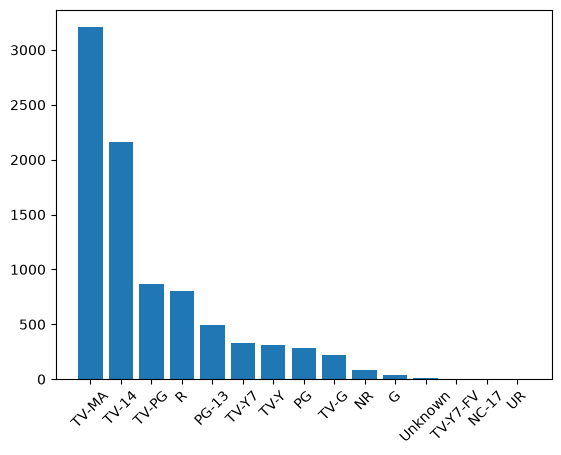

In [38]:
plt.bar(rating_counts.index, rating_counts.values)
plt.xticks(rotation=45)

#### 映画

rating
TV-MA       2062
TV-14       1427
R            797
TV-PG        540
PG-13        490
PG           287
TV-Y7        139
TV-Y         131
TV-G         126
NR            75
G             41
Unknown        5
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'TV-MA'),
  Text(1, 0, 'TV-14'),
  Text(2, 0, 'R'),
  Text(3, 0, 'TV-PG'),
  Text(4, 0, 'PG-13'),
  Text(5, 0, 'PG'),
  Text(6, 0, 'TV-Y7'),
  Text(7, 0, 'TV-Y'),
  Text(8, 0, 'TV-G'),
  Text(9, 0, 'NR'),
  Text(10, 0, 'G'),
  Text(11, 0, 'Unknown'),
  Text(12, 0, 'TV-Y7-FV'),
  Text(13, 0, 'NC-17'),
  Text(14, 0, 'UR')])

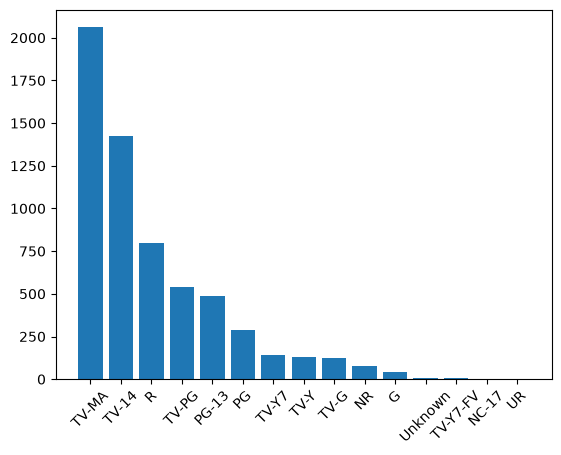

In [39]:
movie_counts = movies["rating"].value_counts()
print(movie_counts)

plt.bar(movie_counts.index, movie_counts.values)
plt.xticks(rotation=45)

#### TV

rating
TV-MA       1145
TV-14        733
TV-PG        323
TV-Y7        195
TV-Y         176
TV-G          94
NR             5
R              2
Unknown        2
TV-Y7-FV       1
Name: count, dtype: int64


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'TV-MA'),
  Text(1, 0, 'TV-14'),
  Text(2, 0, 'TV-PG'),
  Text(3, 0, 'TV-Y7'),
  Text(4, 0, 'TV-Y'),
  Text(5, 0, 'TV-G'),
  Text(6, 0, 'NR'),
  Text(7, 0, 'R'),
  Text(8, 0, 'Unknown'),
  Text(9, 0, 'TV-Y7-FV')])

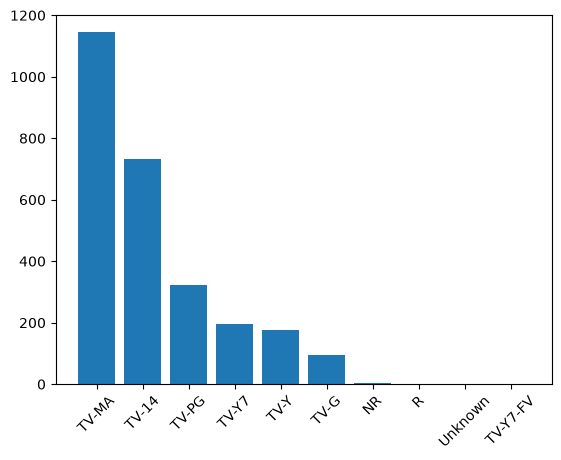

In [40]:
TV_rating = TV["rating"].value_counts()
print(TV_rating)

plt.bar(TV_rating.index, TV_rating.values)
plt.xticks(rotation=45)

## キャスト・監督（cast/director）

### 最多（グラフ付き）

#### 監督

In [41]:
director_counts = df["director"].str.split(", ").explode()
director_counts = director_counts[director_counts != "Unknown"].value_counts()
print(director_counts.head(10))

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64


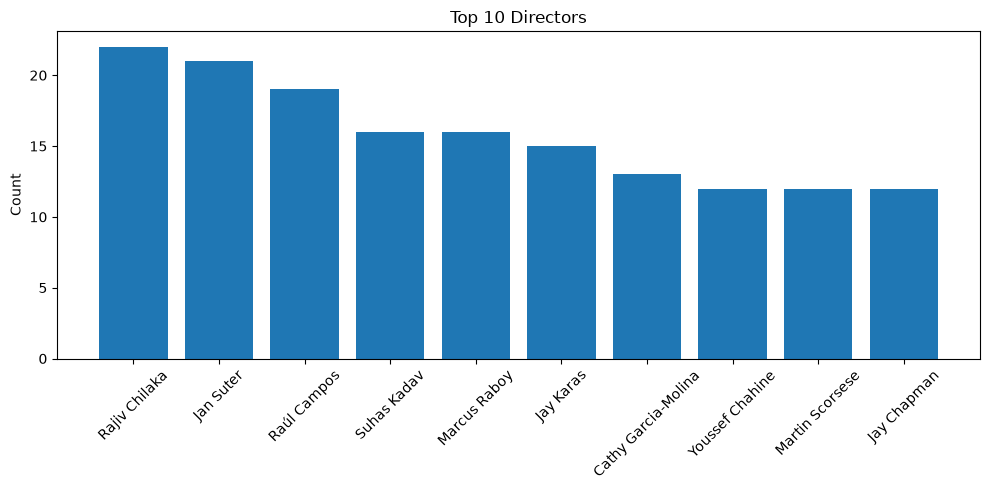

In [42]:
director_top10 = director_counts.head(10)
plt.figure(figsize=(10,5))
plt.bar(director_top10.index, director_top10.values)
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Top 10 Directors")
plt.tight_layout()
plt.show()

#### キャスト

In [43]:
cast_counts = df["cast"].str.split(", ").explode()
cast_counts = cast_counts[cast_counts != "Unknown"].value_counts()
print(cast_counts.head(10))

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64


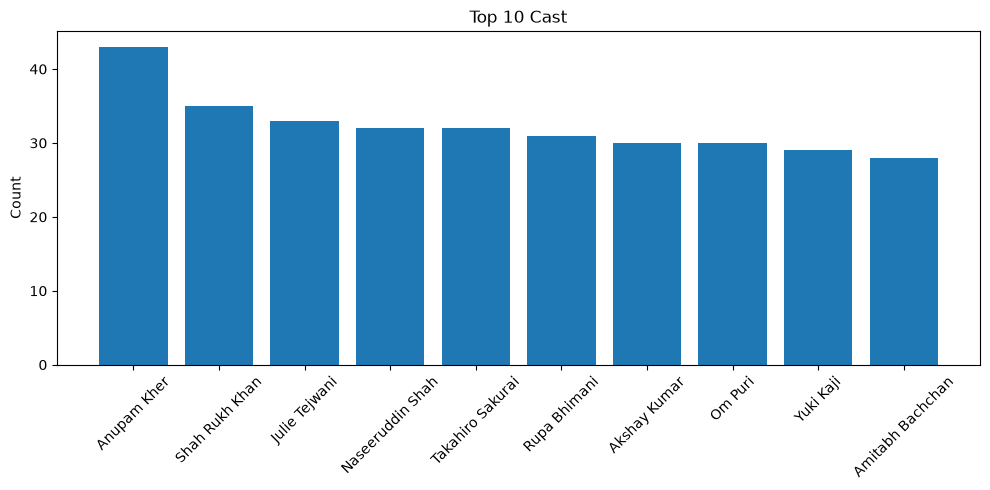

In [44]:
cast_top10 = cast_counts.head(10)
plt.figure(figsize=(10,5))
plt.bar(cast_top10.index, cast_top10.values)
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Top 10 Cast")
plt.tight_layout()
plt.show()

### 国別
各国で一番の監督・キャスト

#### 監督

In [45]:
director_country = df.copy()

director_country["country"] = director_country["country"].str.split(", ")
director_country["director"] = director_country["director"].str.split(", ")

director_country = director_country.explode("country")
director_country = director_country.explode("director")

director_country = director_country[(director_country["country"]!="Unknown")&
    (director_country["director"]!="Unknown")]

director_country = director_country.groupby(["country", "director"]).size().reset_index(name="count")

top_director = director_country.loc[director_country.groupby("country")["count"].idxmax()]

top_director = top_director.sort_values("count", ascending=False)

print(top_director.head(10))

            country             director  count
5241  United States            Jay Karas     15
3093    Philippines  Cathy Garcia-Molina     13
983           Egypt      Youssef Chahine     12
2830         Mexico            Jan Suter     12
3758         Turkey       Yılmaz Erdoğan      9
1706          India       Anurag Kashyap      9
1566      Hong Kong           Johnnie To      8
2381      Indonesia     Hanung Bramantyo      8
529          Canada       Justin G. Dyck      8
2685          Japan    Toshiya Shinohara      7


#### キャスト

In [46]:
cast_country = df.copy()

cast_country["country"] = cast_country["country"].str.split(", ")
cast_country["cast"] = cast_country["cast"].str.split(", ")

cast_country = cast_country.explode("country")
cast_country = cast_country.explode("cast")

cast_country = cast_country[(cast_country["country"]!="Unknown")&
    (cast_country["cast"]!="Unknown")]

cast_country = cast_country.groupby(["country", "cast"]).size().reset_index(name="count")

top_cast = cast_country.loc[cast_country.groupby("country")["count"].idxmax()]

top_cast = top_cast.sort_values("count", ascending=False)

print(top_cast)

               country                cast  count
14214            India         Anupam Kher     40
20915            Japan    Takahiro Sakurai     29
48379    United States   Samuel L. Jackson     22
32592   United Kingdom  David Attenborough     17
4388            Canada  John Paul Tremblay     14
...                ...                 ...    ...
35622  United Kingdom,         Ala' Hanani      1
50786     Vatican City        Pope Francis      1
50787        Venezuela      Andrea Garrote      1
50836     West Germany     Christopher Lee      1
50877         Zimbabwe    Charmaine Mujeri      1

[119 rows x 3 columns]


### 監督・キャスト 別
各監督・キャストが最も多く作品を制作・出演した国

#### 監督

In [47]:
director_country = df.copy()

director_country["country"] = director_country["country"].str.split(", ")
director_country["director"] = director_country["director"].str.split(", ")

director_country = director_country.explode("country")
director_country = director_country.explode("director")

director_country = director_country[(director_country["country"]!="Unknown")&
    (director_country["director"]!="Unknown")]

director_country = director_country.groupby(["country", "director"]).size().reset_index(name="count")

top_director = director_country.loc[director_country.groupby("director")["count"].idxmax()]

top_director = top_director.sort_values("count", ascending=False)

print(top_director)

            country                director  count
5241  United States               Jay Karas     15
5707  United States            Marcus Raboy     15
3093    Philippines     Cathy Garcia-Molina     13
2830         Mexico               Jan Suter     12
5240  United States             Jay Chapman     12
...             ...                     ...    ...
846        Colombia           Jorge Granier      1
2836         Mexico  Jorge Hernandez Aldana      1
3473          Spain        Jorge M. Fontana      1
2837         Mexico       Jorge Michel Grau      1
520          Canada          Jonathan Sobol      1

[4739 rows x 3 columns]


#### キャスト

In [48]:
cast_country = df.copy()

cast_country["country"] = cast_country["country"].str.split(", ")
cast_country["cast"] = cast_country["cast"].str.split(", ")

cast_country = cast_country.explode("country")
cast_country = cast_country.explode("cast")

cast_country = cast_country[(cast_country["country"]!="Unknown")&
    (cast_country["cast"]!="Unknown")]

cast_country = cast_country.groupby(["country", "cast"]).size().reset_index(name="count")

top_cast = cast_country.loc[cast_country.groupby("cast")["count"].idxmax()]

top_cast = top_cast.sort_values("count", ascending=False)

print(top_cast)

      country              cast  count
14214   India       Anupam Kher     40
16854   India    Shah Rukh Khan     34
15860   India  Naseeruddin Shah     31
20915   Japan  Takahiro Sakurai     29
16010   India           Om Puri     29
...       ...               ...    ...
31477  Turkey      Şenay Gürler      1
31476  Turkey    Şenay Bozoklar      1
31475  Turkey    Şehsuvar Aktaş      1
31474  Turkey     Şebnem Sönmez      1
31470  Turkey    Şafak Pekdemir      1

[34321 rows x 3 columns]


### 日本

#### 監督

     country           director  count
2685   Japan  Toshiya Shinohara      7
2638   Japan    Masahiko Murata      5
2660   Japan      Shigeaki Kubo      4
2608   Japan   Hiroyuki Seshita      4
2648   Japan       Noriyuki Abe      3
2616   Japan     Kazuchika Kise      3
2687   Japan  Toshiyuki Kubooka      3
2624   Japan      Kobun Shizuno      3
2644   Japan       Naoko Yamada      2
2698   Japan   Yoshiyuki Momose      2


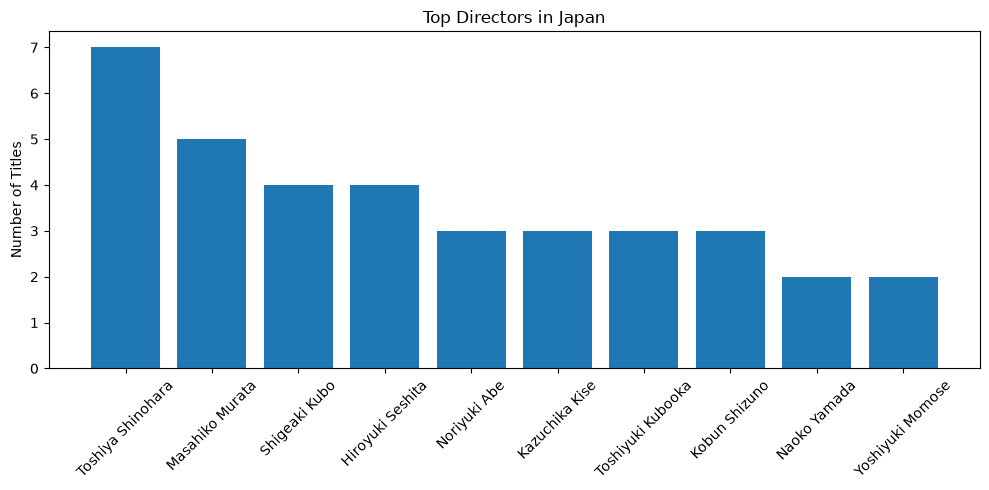

In [49]:
jp_dire_country = director_country[director_country["country"] == "Japan"]
jp_dire_country = jp_dire_country[jp_dire_country["director"] != "Unknown"]
top10 = jp_dire_country.sort_values("count", ascending=False).head(10)
print(top10)

plt.figure(figsize=(10,5))
plt.bar(top10["director"], top10["count"])
plt.xticks(rotation=45)
plt.ylabel("Number of Titles")
plt.title("Top Directors in Japan")
plt.tight_layout()
plt.show()

#### キャスト

      country              cast  count
20915   Japan  Takahiro Sakurai     29
21166   Japan         Yuki Kaji     28
19684   Japan       Daisuke Ono     22
20024   Japan    Junichi Suwabe     19
20055   Japan     Kana Hanazawa     18
21149   Japan   Yuichi Nakamura     18
19444   Japan         Ai Kayano     18
20311   Japan     Mamoru Miyano     18
21115   Japan  Yoshimasa Hosoya     16
21013   Japan   Tomokazu Sugita     16


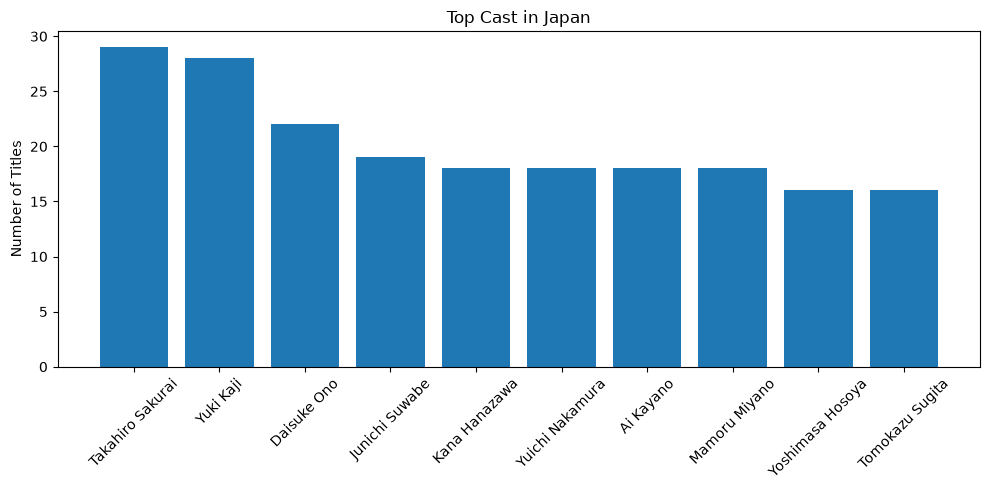

In [50]:
jp_cast_country = cast_country[cast_country["country"] == "Japan"]
jp_cast_country = jp_cast_country[jp_cast_country["cast"] != "Unknown"]
top10 = jp_cast_country.sort_values("count", ascending=False).head(10)
print(top10)

plt.figure(figsize=(10,5))
plt.bar(top10["cast"], top10["count"])
plt.xticks(rotation=45)
plt.ylabel("Number of Titles")
plt.title("Top Cast in Japan")
plt.tight_layout()
plt.show()

### 監督×キャスト

             director                cast  count
35337   Rajiv Chilaka         Rajesh Kava     19
35331   Rajiv Chilaka       Julie Tejwani     19
35338   Rajiv Chilaka        Rupa Bhimani     18
35330   Rajiv Chilaka      Jigna Bhardwaj     18
35345   Rajiv Chilaka        Vatsal Dubey     16
35343   Rajiv Chilaka             Swapnil     13
35334   Rajiv Chilaka              Mousam     13
43028     Suhas Kadav  Saurav Chakraborty      8
38629  S.S. Rajamouli      Anushka Shetty      7
38630  S.S. Rajamouli              Nassar      7


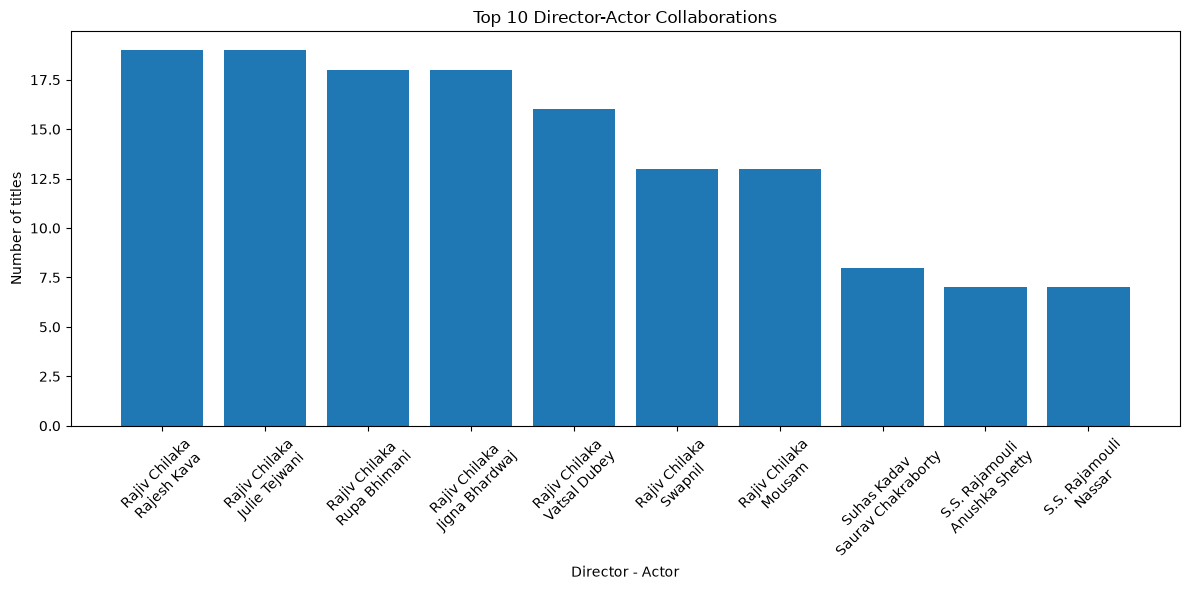

In [51]:
director_actor = df.copy()

# Unknownを除外
director_actor = director_actor[(director_actor["director"] != "Unknown") 
    & (director_actor["cast"] != "Unknown")]

# カンマ区切りをリスト化
director_actor["director"] = director_actor["director"].str.split(", ")
director_actor["cast"] = director_actor["cast"].str.split(", ")

# 一人ずつにする
director_actor = director_actor.explode("director")
director_actor = director_actor.explode("cast")

# 監督×俳優の作品数を集計
director_actor_count = (director_actor.groupby(["director", "cast"]).size().reset_index(name="count"))

# 多い順
director_actor_count = director_actor_count.sort_values("count", ascending=False)

top10 = director_actor_count.head(10)
print(top10)

plt.figure(figsize=(12, 6))
plt.bar(top10["director"] + "\n" + top10["cast"], top10["count"])
plt.xticks(rotation=45)
plt.xlabel("Director - Actor")
plt.ylabel("Number of titles")
plt.title("Top 10 Director-Actor Collaborations")
plt.tight_layout()
plt.show()

### キャスト×キャスト

                actor1         actor2  count
202606   Julie Tejwani   Rupa Bhimani     31
202602   Julie Tejwani    Rajesh Kava     24
270165     Rajesh Kava   Rupa Bhimani     22
188818  Jigna Bhardwaj  Julie Tejwani     21
188833  Jigna Bhardwaj   Rupa Bhimani     20
188831  Jigna Bhardwaj    Rajesh Kava     20
188843  Jigna Bhardwaj   Vatsal Dubey     18
202616   Julie Tejwani   Vatsal Dubey     18
276069    Rupa Bhimani   Vatsal Dubey     18
270176     Rajesh Kava   Vatsal Dubey     17


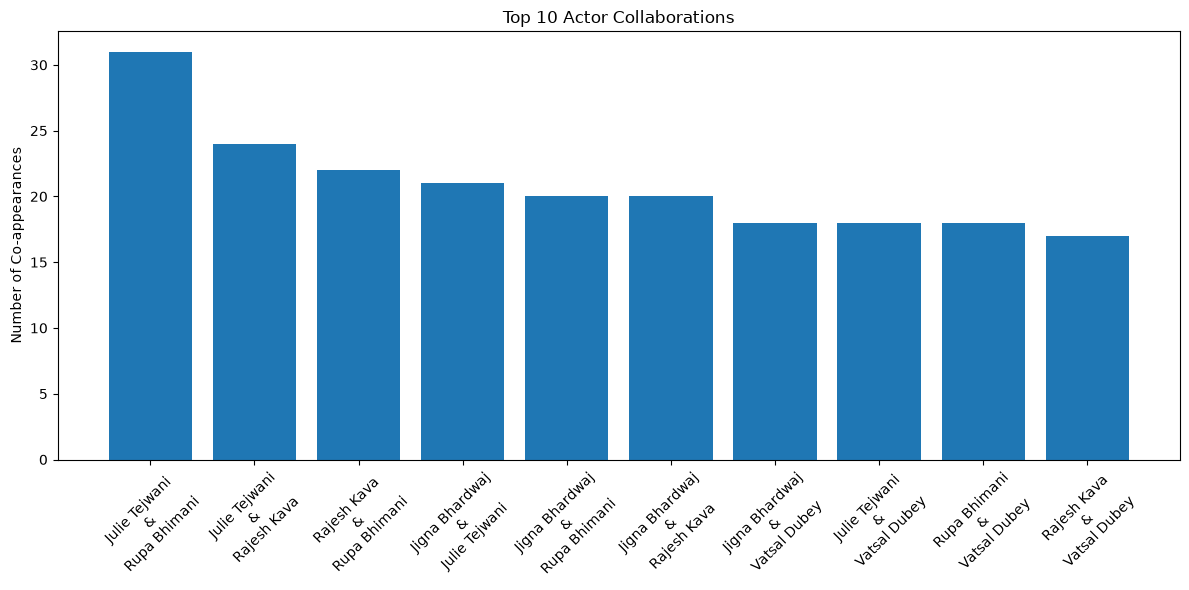

In [52]:
# Unknownを除外
actor_df = df[df["cast"] != "Unknown"].copy()

pairs = []

for cast in actor_df["cast"].dropna():
    # 俳優をリスト化
    actors = [actor.strip() for actor in cast.split(", ")]
    # 同じ俳優が重複しないようにする
    actors = list(set(actors))
    # 2人組を作る
    for pair in combinations(sorted(actors), 2):
        pairs.append(pair)

# DataFrame化
pair_df = pd.DataFrame(pairs, columns=["actor1", "actor2"])

# 共演回数を数える
pair_count = (pair_df.groupby(["actor1", "actor2"]).size().reset_index(name="count").sort_values("count", ascending=False))

top10 = pair_count.head(10)
print(top10)

plt.figure(figsize=(12, 6))
plt.bar(top10["actor1"] + "\n&\n" + top10["actor2"], top10["count"])

plt.xticks(rotation=45)
plt.ylabel("Number of Co-appearances")
plt.title("Top 10 Actor Collaborations")
plt.tight_layout()
plt.show()

### 監督×キャスト（日本）

In [53]:
jp = df[df["country"].str.contains("Japan", na=False)].copy()

# Unknownを除外
jp = jp[(jp["director"] != "Unknown") & (jp["cast"] != "Unknown")]

# 分割
jp["director"] = jp["director"].str.split(", ")
jp["cast"] = jp["cast"].str.split(", ")

# 一人ずつ展開
jp = jp.explode("director")
jp = jp.explode("cast")

# 組み合わせを集計
director_actor = (jp.groupby(["director", "cast"]).size().reset_index(name="count").sort_values("count", ascending=False))

print(director_actor.head(10))

               director              cast  count
1104  Toshiya Shinohara    Satsuki Yukino      7
1097  Toshiya Shinohara   Kumiko Watanabe      7
1096  Toshiya Shinohara    Koji Tsujitani      7
1092  Toshiya Shinohara  Kappei Yamaguchi      7
1090  Toshiya Shinohara   Houko Kuwashima      7
1102  Toshiya Shinohara     Noriko Hidaka      5
1093  Toshiya Shinohara        Ken Narita      5
852       Shigeaki Kubo      Keiji Kuroki      4
850       Shigeaki Kubo    Hiroomi Tosaka      4
584     Masahiko Murata     Chie Nakamura      4


### キャスト×キャスト（日本）

In [54]:
jp = df[df["country"].str.contains("Japan", na=False)].copy()

# Unknownを除外
jp = jp[jp["cast"] != "Unknown"]

pairs = []

for cast in jp["cast"].dropna():
    # 俳優をリスト化
    actors = [a.strip() for a in cast.split(", ")]
    # 重複を削除
    actors = sorted(set(actors))
    # 共演ペアを作る
    pairs.extend(combinations(actors, 2))

# 集計
pair_df = pd.DataFrame(pairs, columns=["actor1", "actor2"])

pair_count = (
    pair_df.groupby(["actor1", "actor2"]).size().reset_index(name="count").sort_values("count", ascending=False)
)

print(pair_count.head(10))

                 actor1            actor2  count
18292  Takahiro Sakurai         Yuki Kaji     12
4818        Daisuke Ono         Yuki Kaji     12
3799      Chie Nakamura    Junko Takeuchi     10
18268  Takahiro Sakurai   Tomokazu Sugita      9
4788        Daisuke Ono  Takahiro Sakurai      9
10125     Kana Hanazawa  Takahiro Sakurai      9
13735     Mamoru Miyano         Yuki Kaji      9
13714     Mamoru Miyano  Takahiro Sakurai      9
3801      Chie Nakamura    Kazuhiko Inoue      8
12598    Koji Tsujitani    Satsuki Yukino      8


# 時系列分析

## 年ごとの作品数の推移

### add_year

add_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


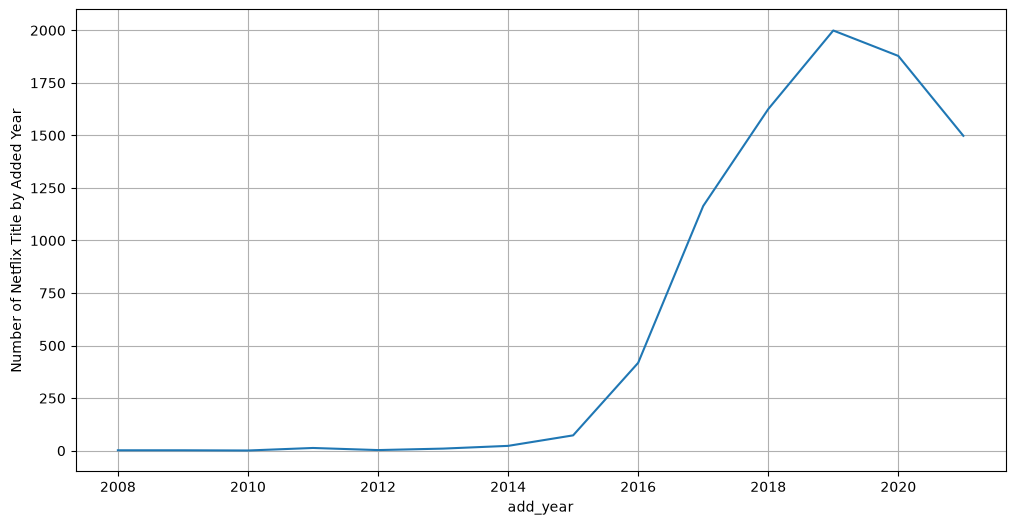

In [55]:
add_year_count = df["add_year"].value_counts().sort_index()
print(add_year_count)

plt.figure(figsize=(12, 6))
plt.plot(add_year_count.index, add_year_count.values)
plt.xlabel("add_year")
plt.ylabel("Number of Netflix Title by Added Year")
plt.grid(True)
plt.show()

### add_month

add_month
1.0     727
2.0     557
3.0     734
4.0     759
5.0     626
6.0     724
7.0     819
8.0     749
9.0     765
10.0    755
11.0    697
12.0    797
Name: count, dtype: int64


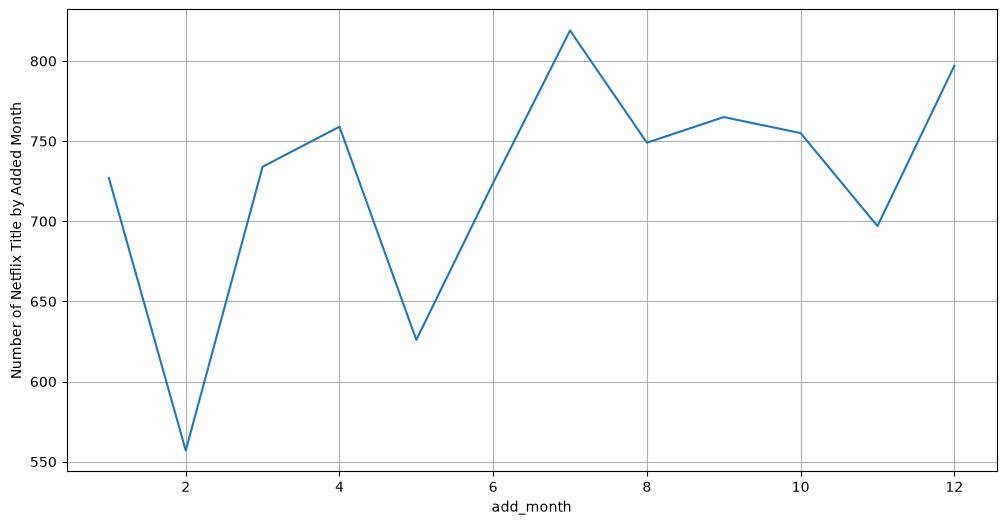

In [56]:
add_month_count = df["add_month"].value_counts().sort_index()
print(add_month_count)

plt.figure(figsize=(12, 6))
plt.plot(add_month_count.index, add_month_count.values)
plt.xlabel("add_month")
plt.ylabel("Number of Netflix Title by Added Month")
plt.grid(True)
plt.show()

### release_year

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


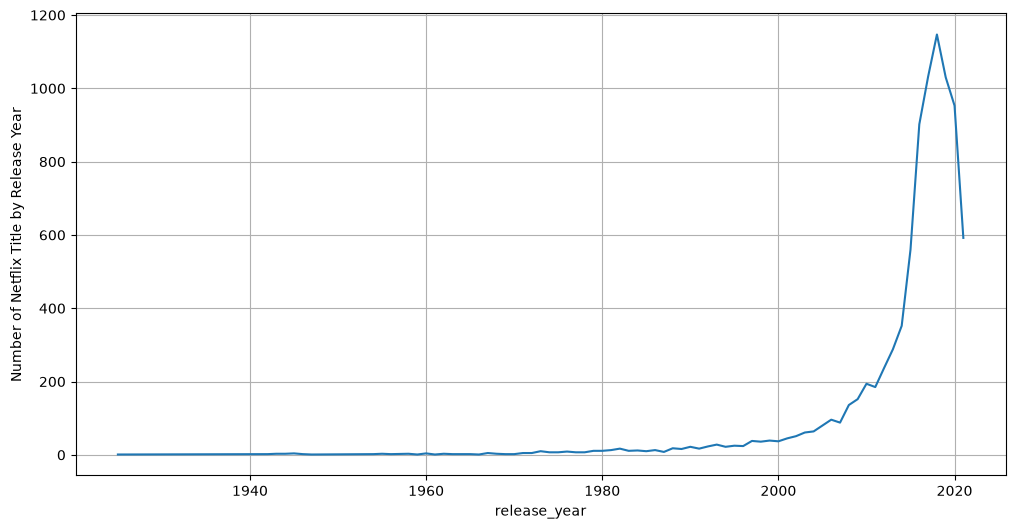

In [57]:
release_year_count = df["release_year"].value_counts().sort_index()
print(release_year_count)

plt.figure(figsize=(12, 6))
plt.plot(release_year_count.index, release_year_count.values)
plt.xlabel("release_year")
plt.ylabel("Number of Netflix Title by Release Year")
plt.grid(True)
plt.show()

## 映画とTVの推移

### add_year

type      Movie  TV Show
add_year                
2008.0        1        1
2009.0        2        0
2010.0        1        0
2011.0       13        0
2012.0        3        0
2013.0        6        4
2014.0       19        4
2015.0       56       17
2016.0      253      165
2017.0      839      325
2018.0     1237      388
2019.0     1424      575
2020.0     1284      594
2021.0      993      505


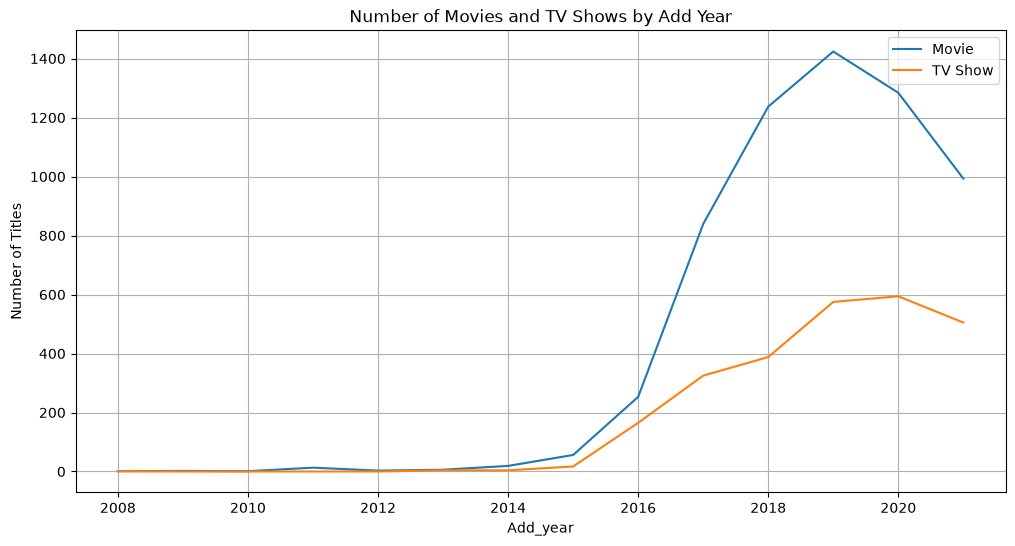

In [58]:
type_add_year = df.groupby(["add_year", "type"]).size().unstack(fill_value=0)
print(type_add_year)

plt.figure(figsize=(12, 6))
plt.plot(type_add_year.index, type_add_year["Movie"], label="Movie")
plt.plot(type_add_year.index, type_add_year["TV Show"], label="TV Show")
plt.xlabel("Add_year")
plt.ylabel("Number of Titles")
plt.title("Number of Movies and TV Shows by Add Year")
plt.legend()
plt.grid(True)
plt.show()

### release_year

type          Movie  TV Show
release_year                
1925              0        1
1942              2        0
1943              3        0
1944              3        0
1945              3        1
...             ...      ...
2017            767      265
2018            767      380
2019            633      397
2020            517      436
2021            277      315

[74 rows x 2 columns]


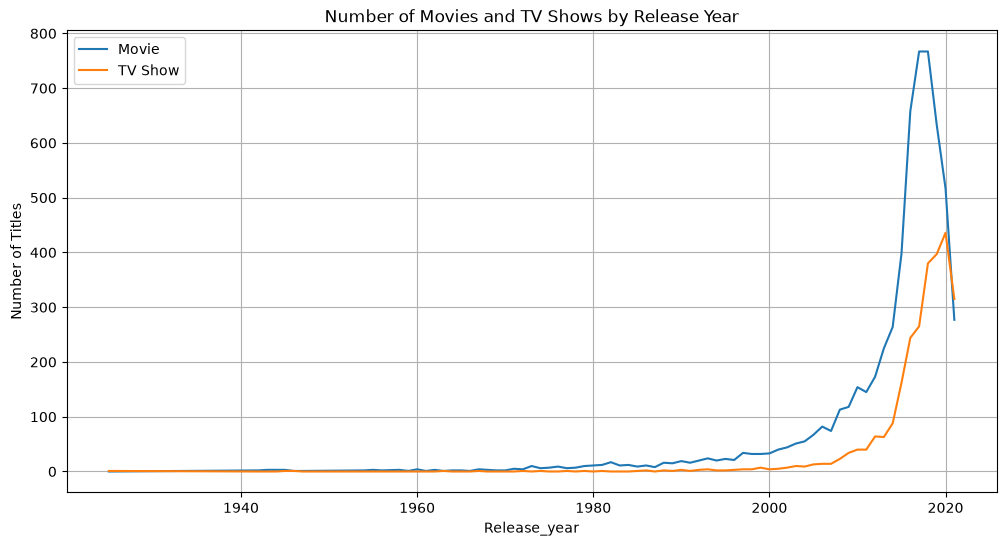

In [59]:
type_release_year = df.groupby(["release_year", "type"]).size().unstack(fill_value=0)
print(type_release_year)

plt.figure(figsize=(12, 6))
plt.plot(type_release_year.index, type_release_year["Movie"], label="Movie")
plt.plot(type_release_year.index, type_release_year["TV Show"], label="TV Show")
plt.xlabel("Release_year")
plt.ylabel("Number of Titles")
plt.title("Number of Movies and TV Shows by Release Year")
plt.legend()
plt.grid(True)
plt.show()

## Ratingの変化

### add_year

rating     G  NC-17  NR  PG  PG-13    R  TV-14  TV-G  TV-MA  TV-PG  TV-Y  \
add_year                                                                   
2008.0     0      0   0   0      0    0      0     0      2      0     0   
2009.0     0      0   0   0      0    0      0     0      2      0     0   
2010.0     0      0   1   0      0    0      0     0      0      0     0   
2011.0     0      0   0   0      0    0      5     0      3      5     0   
2012.0     0      0   0   1      0    1      0     0      0      1     0   
2013.0     0      0   4   1      0    0      1     1      3      0     0   
2014.0     1      0   0   3      0    0      2     1     12      3     1   
2015.0     1      0   5   2      2    3     11     5     27      7     6   
2016.0     2      1  27   3      6   14     91     9    160     48    10   
2017.0     4      1  23  19     26   66    319    22    443    158    33   
2018.0    12      0  14  33     53  129    448    33    642    179    37   
2019.0     8

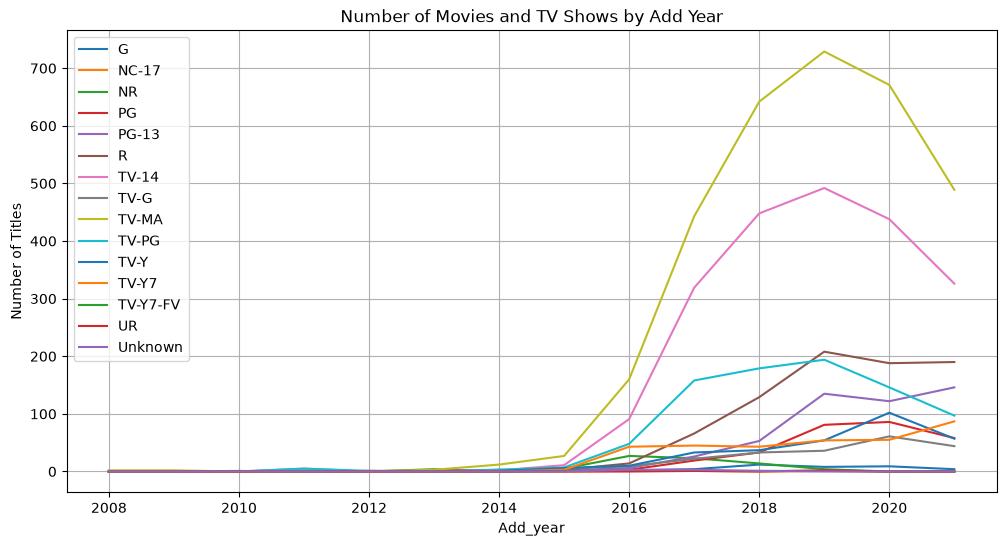

In [60]:
rating_add_year = df.groupby(["add_year", "rating"]).size().unstack(fill_value=0)

print(rating_add_year)

plt.figure(figsize=(12, 6))
for rating in rating_add_year.columns:
    plt.plot(rating_add_year.index, rating_add_year[rating], label=rating)
plt.xlabel("Add_year")
plt.ylabel("Number of Titles")
plt.title("Number of Movies and TV Shows by Add Year")
plt.legend()
plt.grid(True)
plt.show()

### release_year

rating        G  NC-17  NR  PG  PG-13   R  TV-14  TV-G  TV-MA  TV-PG  TV-Y  \
release_year                                                                 
1925          0      0   0   0      0   0      1     0      0      0     0   
1942          0      0   0   0      0   0      2     0      0      0     0   
1943          0      0   0   0      0   0      0     0      0      3     0   
1944          0      0   0   0      0   0      2     0      0      1     0   
1945          0      0   0   0      0   0      2     0      2      0     0   
...          ..    ...  ..  ..    ...  ..    ...   ...    ...    ...   ...   
2017          1      0   2  15     32  73    251    26    451    111    31   
2018          2      1   1  31     30  52    268    26    549    105    41   
2019          1      0   0  12     19  39    252    23    500     98    50   
2020          1      0   0  15     21  48    174    45    469     80    59   
2021          0      0   0  11     14  21    151    21    270   

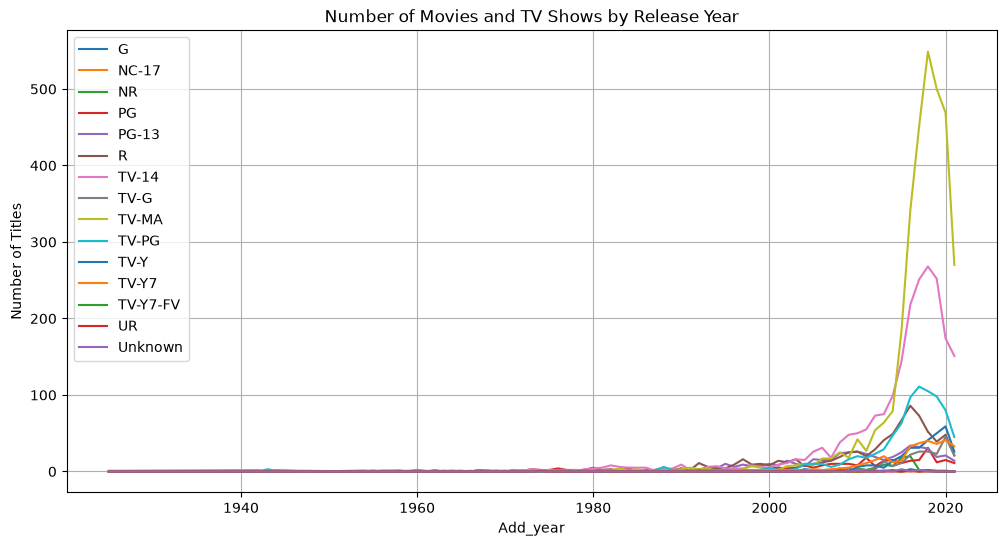

In [61]:
rating_release_year = df.groupby(["release_year", "rating"]).size().unstack(fill_value=0)

print(rating_release_year)

plt.figure(figsize=(12, 6))
for rating in rating_release_year.columns:
    plt.plot(rating_release_year.index, rating_release_year[rating], label=rating)
plt.xlabel("Add_year")
plt.ylabel("Number of Titles")
plt.title("Number of Movies and TV Shows by Release Year")
plt.legend()
plt.grid(True)
plt.show()

### 映画・TV別

#### 映画

##### add_year

rating     G  NC-17  NR  PG  PG-13    R  TV-14  TV-G  TV-MA  TV-PG  TV-Y  \
add_year                                                                   
2008.0     0      0   0   0      0    0      0     0      1      0     0   
2009.0     0      0   0   0      0    0      0     0      2      0     0   
2010.0     0      0   1   0      0    0      0     0      0      0     0   
2011.0     0      0   0   0      0    0      5     0      3      5     0   
2012.0     0      0   0   1      0    1      0     0      0      1     0   
2013.0     0      0   3   1      0    0      0     1      1      0     0   
2014.0     1      0   0   3      0    0      2     0      9      3     1   
2015.0     1      0   5   2      2    3      9     3     24      2     3   
2016.0     2      1  27   3      6   13     40     2    114     25     1   
2017.0     4      1  21  19     26   66    188    14    353    103    19   
2018.0    12      0  14  33     53  129    352    24    456    127    21   
2019.0     8

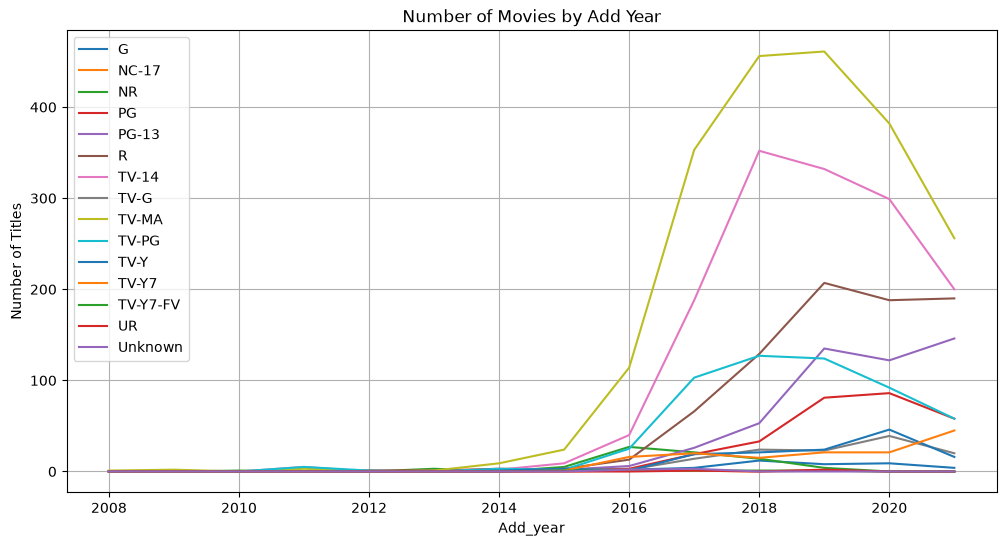

In [62]:
movie = df[df["type"]=="Movie"]
rating_add_year = movie.groupby(["add_year", "rating"]).size().unstack(fill_value=0)

print(rating_add_year)

plt.figure(figsize=(12, 6))
for rating in rating_add_year.columns:
    plt.plot(rating_add_year.index, rating_add_year[rating], label=rating)
plt.xlabel("Add_year")
plt.ylabel("Number of Titles")
plt.title("Number of Movies by Add Year")
plt.legend()
plt.grid(True)
plt.show()

##### release_year

rating        G  NC-17  NR  PG  PG-13   R  TV-14  TV-G  TV-MA  TV-PG  TV-Y  \
release_year                                                                 
1942          0      0   0   0      0   0      2     0      0      0     0   
1943          0      0   0   0      0   0      0     0      0      3     0   
1944          0      0   0   0      0   0      2     0      0      1     0   
1945          0      0   0   0      0   0      2     0      1      0     0   
1946          0      0   0   0      0   0      0     0      0      1     0   
...          ..    ...  ..  ..    ...  ..    ...   ...    ...    ...   ...   
2017          1      0   2  15     32  73    182    20    337     80    13   
2018          2      1   1  31     30  52    176    18    358     71    13   
2019          1      0   0  12     19  39    160    15    286     62    25   
2020          1      0   0  15     21  48     91    26    220     46    34   
2021          0      0   0  11     14  21     73     9    110   

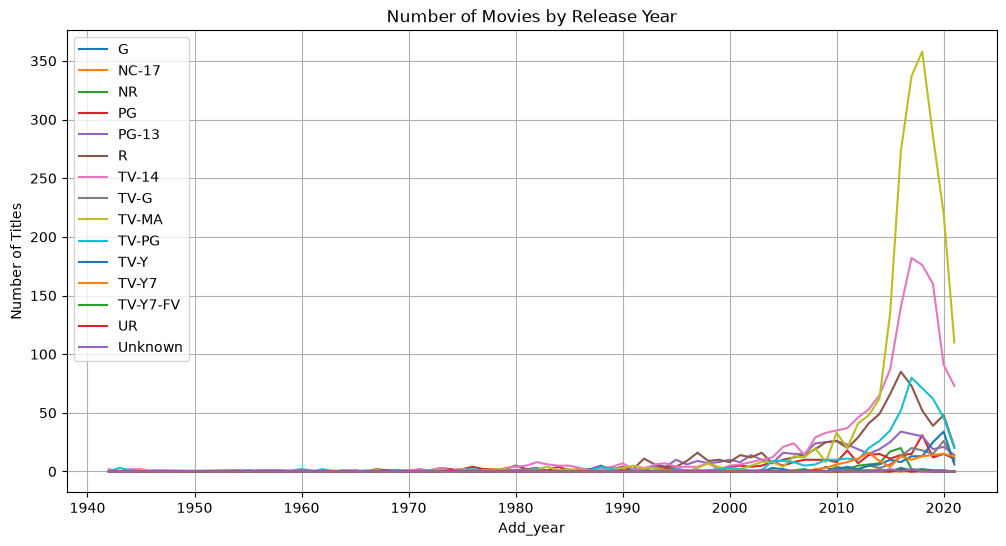

In [63]:
rating_release_year = movie.groupby(["release_year", "rating"]).size().unstack(fill_value=0)

print(rating_release_year)

plt.figure(figsize=(12, 6))
for rating in rating_release_year.columns:
    plt.plot(rating_release_year.index, rating_release_year[rating], label=rating)
plt.xlabel("Add_year")
plt.ylabel("Number of Titles")
plt.title("Number of Movies by Release Year")
plt.legend()
plt.grid(True)
plt.show()

#### TV

##### add_year

rating    TV-MA  NR  TV-14  TV-G  TV-PG  TV-Y  TV-Y7  R  Unknown
add_year                                                        
2008.0        1   0      0     0      0     0      0  0        0
2013.0        2   1      1     0      0     0      0  0        0
2014.0        3   0      0     1      0     0      0  0        0
2015.0        3   0      2     2      5     3      2  0        0
2016.0       46   0     51     7     23     9     27  1        1
2017.0       90   2    131     8     55    14     25  0        0
2018.0      186   0     96     9     52    16     28  0        1
2019.0      268   0    160    13     70    30     33  1        0
2020.0      289   0    139    22     54    56     34  0        0
2021.0      233   0    126    24     39    41     42  0        0


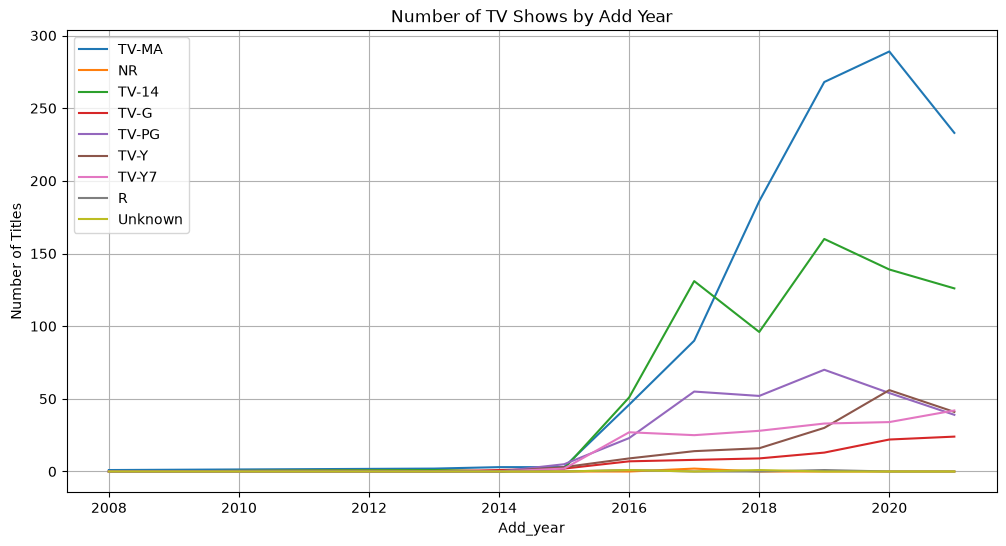

In [64]:
TV = df[df["type"]=="TV Show"]
rating_add_year = TV.groupby(["add_year", "rating"]).size().unstack(fill_value=0)

print(rating_add_year)

plt.figure(figsize=(12, 6))
for rating in rating_add_year.columns:
    plt.plot(rating_add_year.index, rating_add_year[rating], label=rating)
plt.xlabel("Add_year")
plt.ylabel("Number of Titles")
plt.title("Number of TV Shows by Add Year")
plt.legend()
plt.grid(True)
plt.show()

##### release_year

rating        NR  R  TV-14  TV-G  TV-MA  TV-PG  TV-Y  TV-Y7  TV-Y7-FV  Unknown
release_year                                                                  
1925           0  0      1     0      0      0     0      0         0        0
1945           0  0      0     0      1      0     0      0         0        0
1946           0  0      1     0      0      0     0      0         0        0
1963           0  0      1     0      0      0     0      0         0        0
1967           0  0      0     1      0      0     0      0         0        0
1972           0  0      0     0      1      0     0      0         0        0
1974           0  0      1     0      0      0     0      0         0        0
1977           0  0      0     0      0      1     0      0         0        0
1979           0  0      0     0      0      1     0      0         0        0
1981           0  0      0     0      0      0     0      1         0        0
1985           0  0      0     0      1      0     0

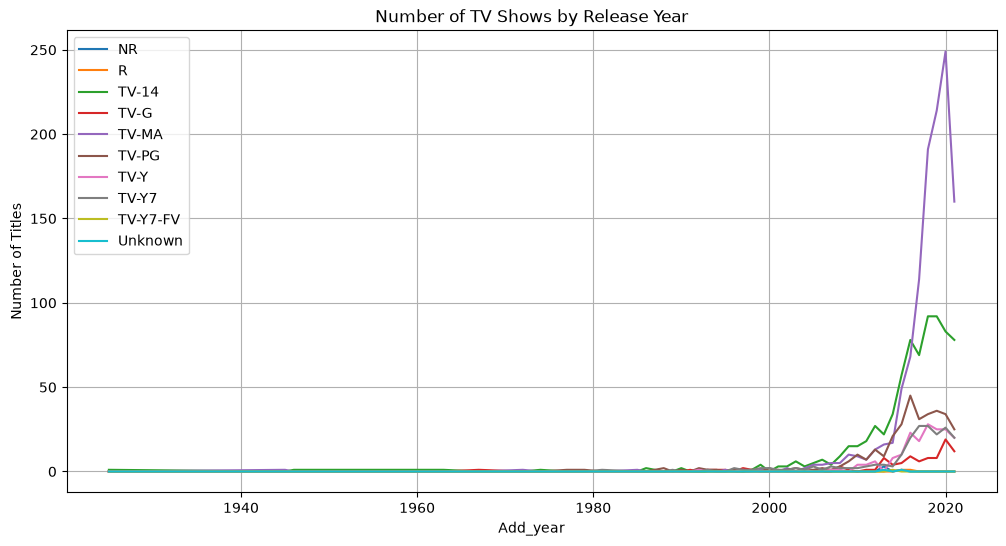

In [65]:
rating_release_year = TV.groupby(["release_year", "rating"]).size().unstack(fill_value=0)

print(rating_release_year)

plt.figure(figsize=(12, 6))
for rating in rating_release_year.columns:
    plt.plot(rating_release_year.index, rating_release_year[rating], label=rating)
plt.xlabel("Add_year")
plt.ylabel("Number of Titles")
plt.title("Number of TV Shows by Release Year")
plt.legend()
plt.grid(True)
plt.show()

## 日本作品の推移

### add_year

type      Movie  TV Show
add_year                
2015.0        0        1
2016.0        5       24
2017.0       17       20
2018.0       13       30
2019.0       29       44
2020.0       31       47
2021.0       24       29


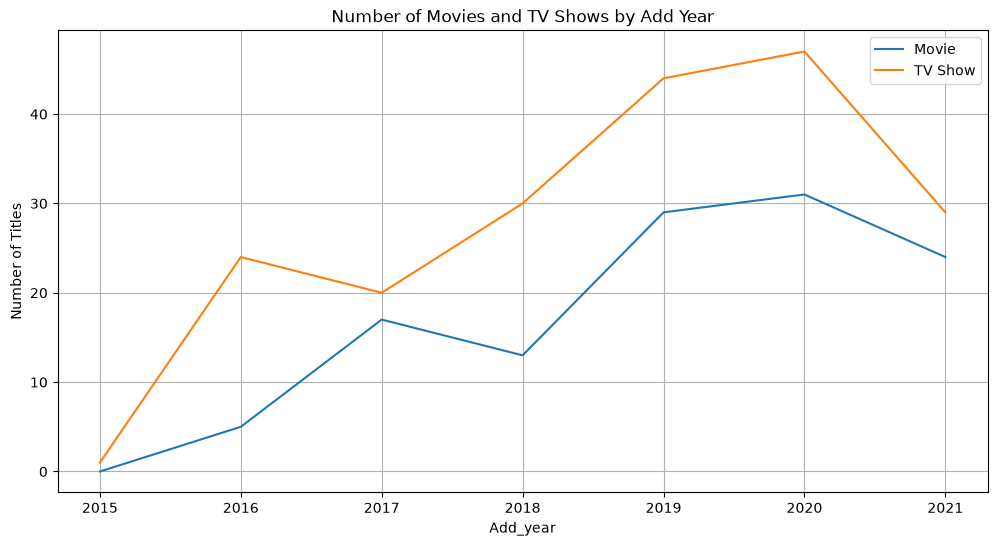

In [66]:
jp = df[df["country"].str.contains("Japan", na=False)].copy()
jp_add_year = jp.groupby(["add_year", "type"]).size().unstack(fill_value=0)

print(jp_add_year)

plt.figure(figsize=(12, 6))
plt.plot(jp_add_year.index, jp_add_year["Movie"], label="Movie")
plt.plot(jp_add_year.index, jp_add_year["TV Show"], label="TV Show")
plt.xlabel("Add_year")
plt.ylabel("Number of Titles")
plt.title("Number of Movies and TV Shows by Add Year")
plt.legend()
plt.grid(True)
plt.show()

### release_year

type          Movie  TV Show
release_year                
1979              1        0
1981              0        1
1985              0        1
1986              0        1
1992              2        0
1993              1        0
1995              0        1
1996              0        1
1997              1        2
1998              1        2
1999              0        2
2000              0        2
2001              1        1
2002              2        2
2003              3        2
2004              3        0
2005              4        1
2006              1        4
2007              1        2
2008              2        8
2009              2        3
2010              5        6
2011              4        6
2012              3        4
2013              6        5
2014              3       13
2015              5       11
2016             12       13
2017             16       21
2018             16       33
2019             12       24
2020              9       15
2021          

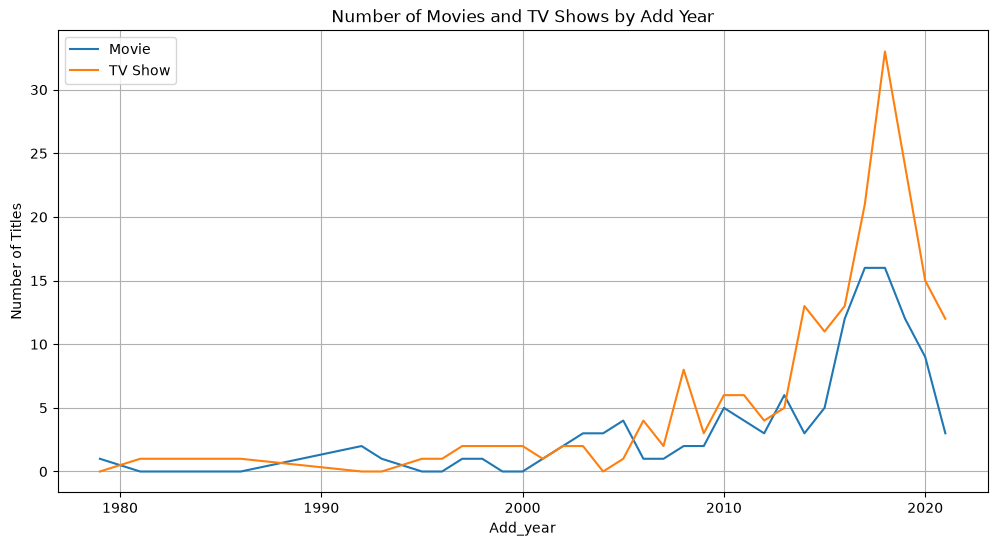

In [67]:
jp = df[df["country"].str.contains("Japan", na=False)].copy()
jp_release_year = jp.groupby(["release_year", "type"]).size().unstack(fill_value=0)

print(jp_release_year)

plt.figure(figsize=(12, 6))
plt.plot(jp_release_year.index, jp_release_year["Movie"], label="Movie")
plt.plot(jp_release_year.index, jp_release_year["TV Show"], label="TV Show")
plt.xlabel("Add_year")
plt.ylabel("Number of Titles")
plt.title("Number of Movies and TV Shows by Add Year")
plt.legend()
plt.grid(True)
plt.show()

## 国別作品数の推移

### add_year

country   Japan  South Korea  United States
add_year                                   
2008.0        0            0              2
2009.0        0            0              1
2010.0        0            0              1
2011.0        0            0             12
2012.0        0            0              3
2013.0        0            0              9
2014.0        0            0             21
2015.0        1            0             50
2016.0       20           10            193
2017.0       33           39            445
2018.0       40           29            585
2019.0       63           57            846
2020.0       68           53            816
2021.0       46           28            625


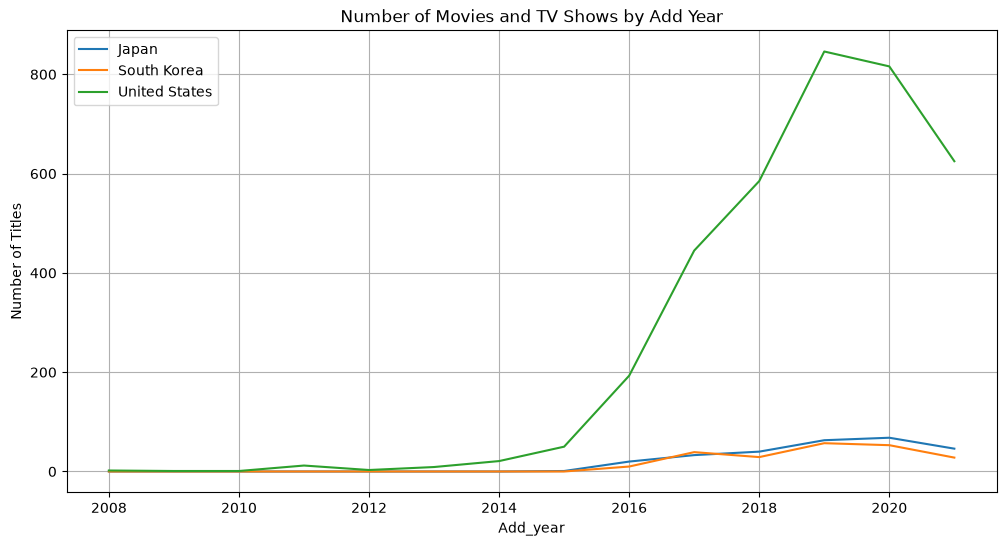

In [68]:
country = df[df["country"].str.contains("Japan|United States|South Korea", na=False)].copy()

country["country"] = country["country"].str.extract(r"(Japan|United States|South Korea)")

country_add_year = country.groupby(["add_year", "country"]).size().unstack(fill_value=0)

print(country_add_year)

plt.figure(figsize=(12, 6))
for c in country_add_year.columns:
    plt.plot(country_add_year.index, country_add_year[c], label=c)

plt.xlabel("Add_year")
plt.ylabel("Number of Titles")
plt.title("Number of Movies and TV Shows by Add Year")

plt.legend()
plt.grid(True)
plt.show()

### release_year

country       Japan  South Korea  United States
release_year                                   
1942              0            0              2
1943              0            0              3
1944              0            0              3
1945              0            0              4
1946              0            0              2
...             ...          ...            ...
2017             34           32            439
2018             46           33            451
2019             29           24            422
2020             22           30            380
2021             12           20            173

[70 rows x 3 columns]


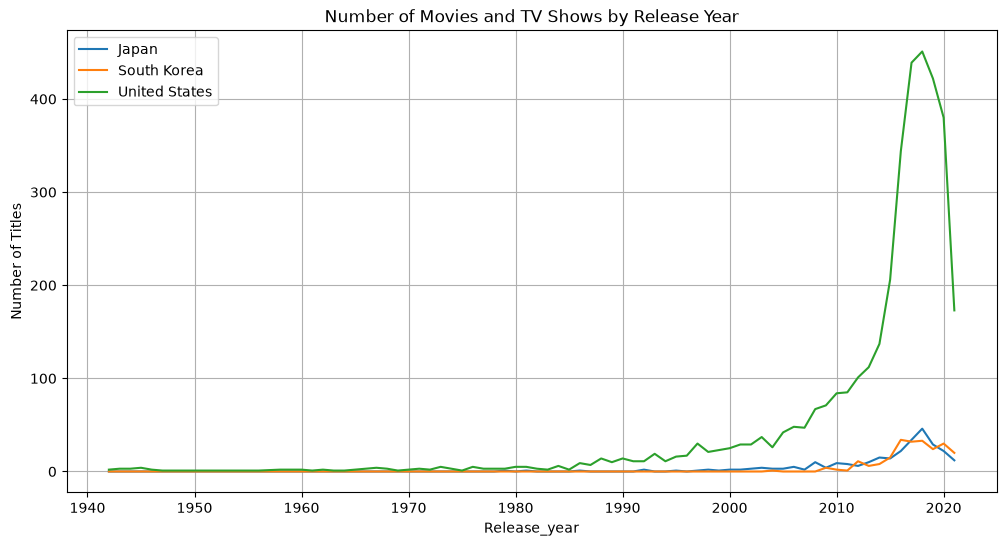

In [69]:
country = df[df["country"].str.contains("Japan|United States|South Korea", na=False)].copy()

country["country"] = country["country"].str.extract(r"(Japan|United States|South Korea)")

country_release_year = country.groupby(["release_year", "country"]).size().unstack(fill_value=0)

print(country_release_year)

plt.figure(figsize=(12, 6))

for c in country_release_year.columns:
    plt.plot(country_release_year.index, country_release_year[c], label=c)

plt.xlabel("Release_year")
plt.ylabel("Number of Titles")
plt.title("Number of Movies and TV Shows by Release Year")

plt.legend()
plt.grid(True)
plt.show()

## 作品時間の変化（映画）

### add_year

add_year
2008.0     81.000000
2009.0     66.500000
2010.0     84.000000
2011.0     93.461538
2012.0     62.000000
2013.0     83.500000
2014.0     77.000000
2015.0     83.571429
2016.0     83.545455
2017.0     95.654350
2018.0    101.739693
2019.0     99.923455
2020.0    101.585670
2021.0    102.839879
Name: duration_min, dtype: float64


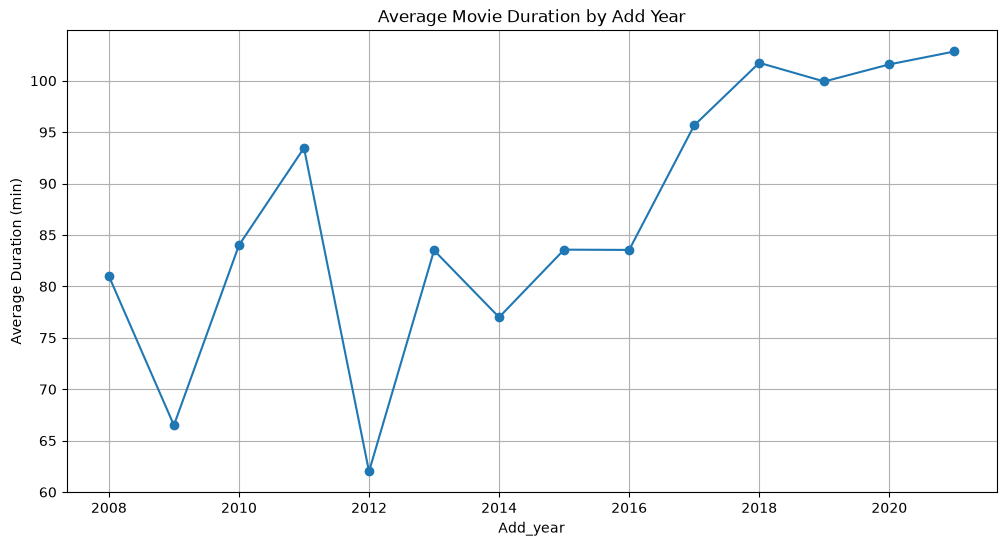

In [70]:
movies = df[df["type"] == "Movie"].copy()

movies["duration_min"] = movies["duration"].str.extract(r"(\d+)").astype(int)

duration_add_year = movies.groupby("add_year")["duration_min"].mean()

print(duration_add_year)

plt.figure(figsize=(12, 6))
plt.plot(duration_add_year.index, duration_add_year.values, marker="o")

plt.xlabel("Add_year")
plt.ylabel("Average Duration (min)")
plt.title("Average Movie Duration by Add Year")

plt.grid(True)
plt.show()

### release_year

release_year
1942    35.000000
1943    62.666667
1944    52.000000
1945    51.333333
1946    58.000000
          ...    
2017    95.507171
2018    96.185137
2019    93.466035
2020    92.141199
2021    96.444043
Name: duration_min, Length: 73, dtype: float64


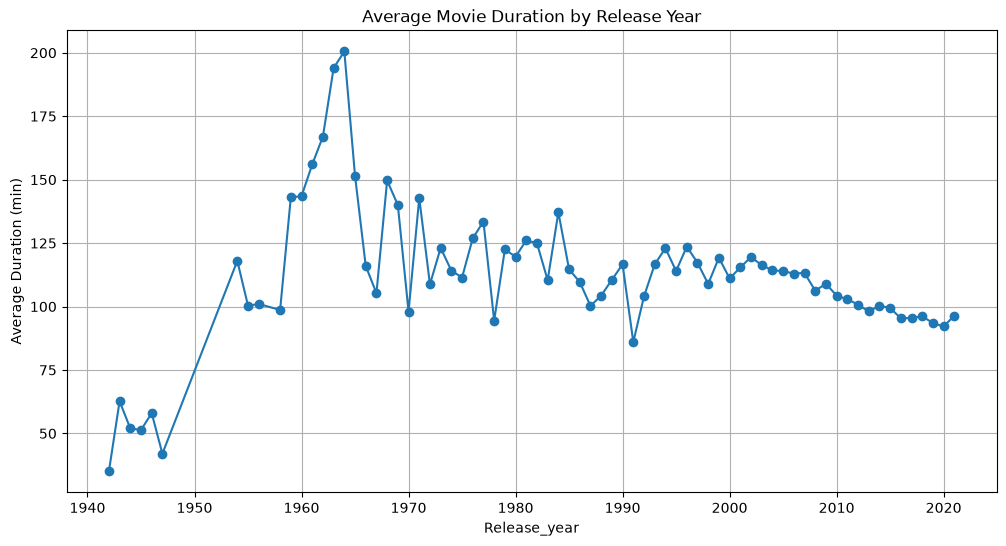

In [71]:
movies = df[df["type"] == "Movie"].copy()

movies["duration_min"] = movies["duration"].str.extract(r"(\d+)").astype(int)

duration_release_year = movies.groupby("release_year")["duration_min"].mean()

print(duration_release_year)

plt.figure(figsize=(12, 6))
plt.plot(duration_release_year.index, duration_release_year.values, marker="o")

plt.xlabel("Release_year")
plt.ylabel("Average Duration (min)")
plt.title("Average Movie Duration by Release Year")

plt.grid(True)
plt.show()

# 文章分析

In [72]:
# descriptionがない行を除外
text_df = df[df["description"] != "Unknown"].copy()

## 説明文の長さ

In [73]:
text_df["description_length"] = text_df["description"].str.len()
print(text_df["description_length"].describe())

count    8807.000000
mean      143.303281
std        10.334959
min        61.000000
25%       140.000000
50%       146.000000
75%       149.000000
max       248.000000
Name: description_length, dtype: float64


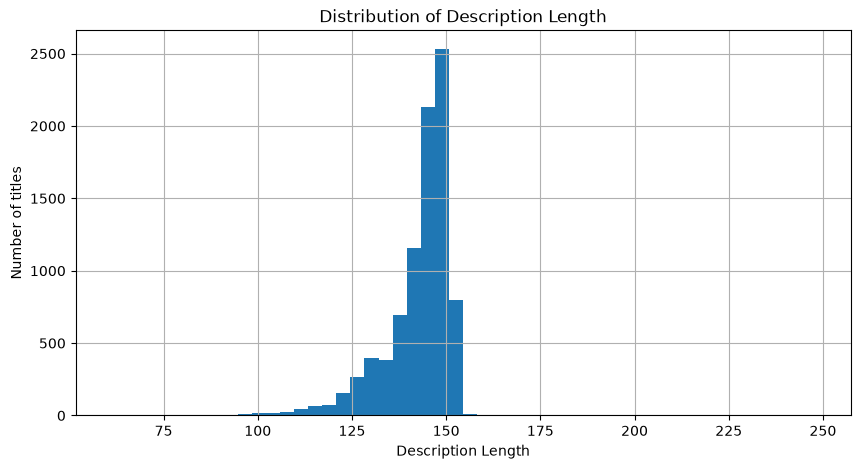

In [74]:
plt.figure(figsize=(10, 5))
plt.hist(text_df["description_length"], bins=50)
plt.xlabel("Description Length")
plt.ylabel("Number of titles")
plt.title("Distribution of Description Length")
plt.grid(True)
plt.show()

## 全作品の頻出単語ランキング

In [75]:
text = text_df["description"]

# テキストデータを数値ベクトルに変換
vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(text)
word_count = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
word_freq = word_count.sum().sort_values(ascending=False)
print(word_freq.head(10))

life       845
young      729
new        709
family     635
world      570
man        538
love       504
woman      486
friends    445
series     396
dtype: int64


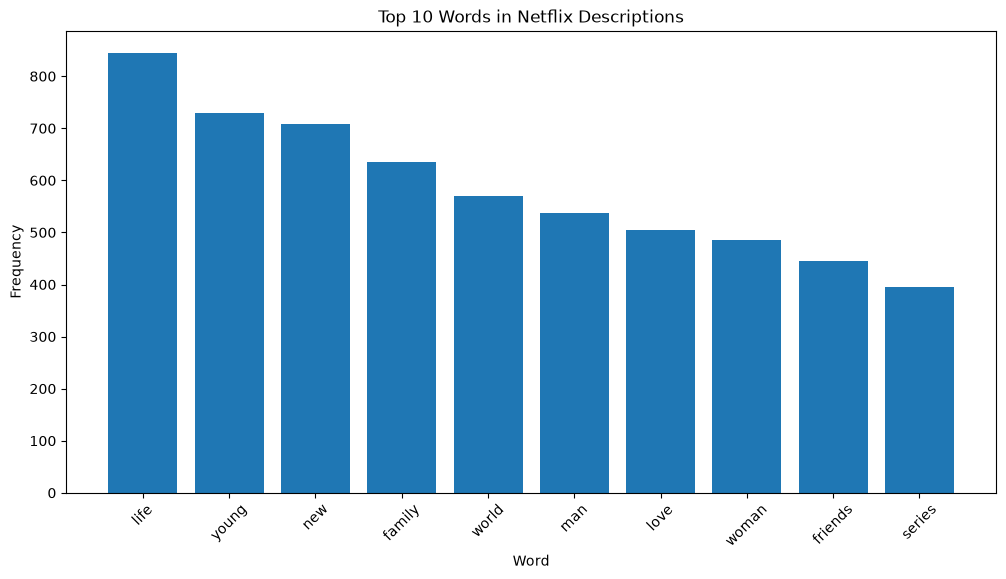

In [76]:
top_words = word_freq.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_words.index, top_words.values)
plt.xticks(rotation=45)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 10 Words in Netflix Descriptions")
plt.show()

## ワードクラウド

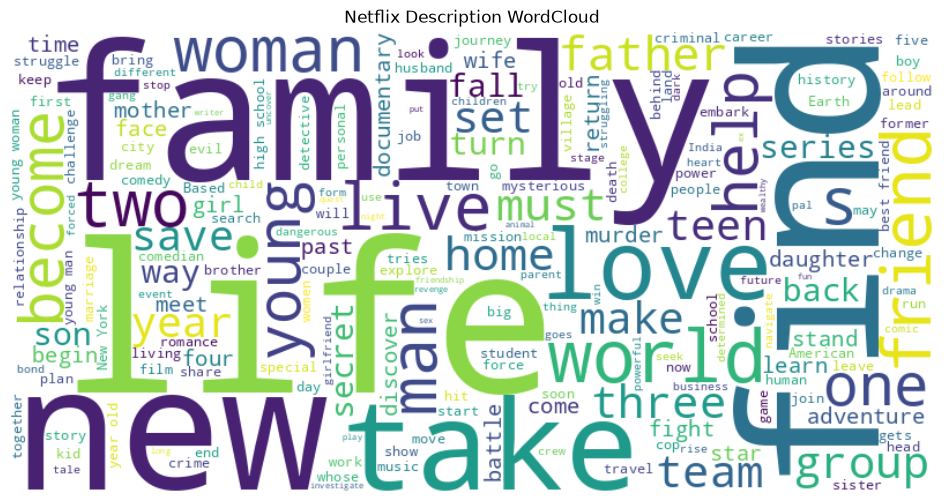

In [77]:
# 複数の文章（文字列）を１つの大きな文章に結合
all_text = " ".join(text_df["description"])

# 作成したWordCloudに文章データを読み込ませて、単語の出現回数を計算
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=STOPWORDS).generate(all_text)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Netflix Description WordCloud")
plt.show()

## MovieとTVの文章比較

### Movie

In [78]:
movie_text = df[df["type"]=="Movie"]["description"].dropna()
movie_vectorizer = CountVectorizer(stop_words="english")
movie_X = movie_vectorizer.fit_transform(movie_text)
movie_words = pd.DataFrame(movie_X.toarray(), columns=movie_vectorizer.get_feature_names_out())
movie_freq = movie_words.sum().sort_values(ascending=False)
print(movie_freq.head(20))

life           573
young          558
new            478
man            452
family         440
woman          383
love           335
documentary    313
world          304
father         261
friends        258
home           237
finds          234
old            233
takes          215
help           199
school         199
girl           185
high           178
lives          176
dtype: int64


### TV

In [79]:
tv_text = df[df["type"]=="TV Show"]["description"].dropna()
tv_vectorizer = CountVectorizer(stop_words="english")
tv_x = tv_vectorizer.fit_transform(tv_text)
tv_words = pd.DataFrame(tv_x.toarray(), columns=tv_vectorizer.get_feature_names_out())
tv_freq = tv_words.sum().sort_values(ascending=False)
print(tv_freq.head(20))

series     311
life       272
world      266
new        231
family     195
friends    187
young      171
love       169
school     140
high       121
woman      103
lives      101
group      100
help        97
man         86
years       84
home        80
true        79
city        79
finds       79
dtype: int64


## 日本作品の文章分析

In [80]:
# 日本作品抽出
jp = df[df["country"].str.contains("Japan", na=False)].dropna(subset=["description"])

### 頻出単語

In [81]:
jp_vectorizer = CountVectorizer(stop_words="english")
jp_X = jp_vectorizer.fit_transform(jp["description"])
jp_words = pd.DataFrame(jp_X.toarray(), columns=jp_vectorizer.get_feature_names_out())
jp_freq = jp_words.sum().sort_values(ascending=False)
print(jp_freq.head(20))

young         41
world         40
high          28
school        28
life          26
new           24
mysterious    21
evil          20
years         18
girl          17
group         17
love          17
battle        16
friends       16
power         15
demon         14
japan         14
schooler      14
lives         14
save          13
dtype: int64


### ワードクラウド

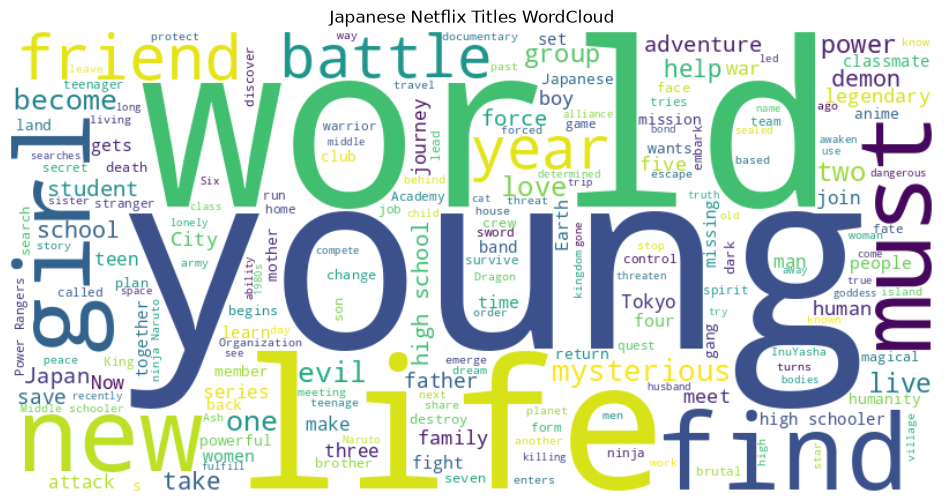

In [82]:
jp_text = " ".join(jp["description"])

# jp_text(文章データ)を読み込んで、WordCloud画像を作成する
jp_wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=STOPWORDS).generate(jp_text)
plt.figure(figsize=(12, 6))
plt.imshow(jp_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Japanese Netflix Titles WordCloud")
plt.show()

## 感情分析
- -1 : ネガティブ
- 0 : 中立
- 1 : ポジティブ

In [83]:
sentiment_df = df[df["description"] != "Unknown"].copy()

In [84]:
# desctiptionを1つずつ感情分析して、感情スコアだけを取り出す処理
sentiment_df["polarity"] = sentiment_df["description"].apply(lambda x: TextBlob(x).sentiment.polarity)
print(sentiment_df[["description", "polarity"]].head())

                                         description  polarity
0  As her father nears the end of his life, filmm...  0.333333
1  After crossing paths at a party, a Cape Town t...  0.000000
2  To protect his family from a powerful drug lor... -0.050000
3  Feuds, flirtations and toilet talk go down amo... -0.030505
4  In a city of coaching centers known to train I...  0.000000


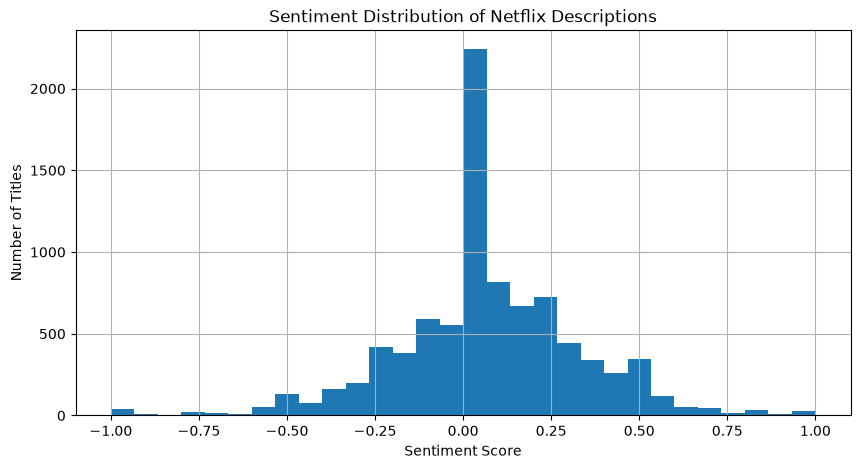

In [85]:
plt.figure(figsize=(10,5))
plt.hist(sentiment_df["polarity"], bins=30)
plt.xlabel("Sentiment Score")
plt.ylabel("Number of Titles")
plt.title("Sentiment Distribution of Netflix Descriptions")
plt.grid(True)
plt.show()

### MovieとTVを比較

In [86]:
print(sentiment_df.groupby("type")["polarity"].mean())

type
Movie      0.050908
TV Show    0.089660
Name: polarity, dtype: float64


## TF-IDF分析
その作品群に特徴的な単語を見つける方法

In [87]:
text = df["description"].dropna()

# 文章を単語の重要度（TF-IDF値）に変換するための機能
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(text)
tfidf = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
score = tfidf.mean().sort_values(ascending=False)
print(score.head(20))

life           0.012828
young          0.011865
new            0.011134
family         0.010589
man            0.009602
world          0.009500
woman          0.009012
love           0.008977
friends        0.008199
series         0.007288
documentary    0.006782
school         0.006534
father         0.006327
home           0.006192
finds          0.006153
old            0.005947
high           0.005838
help           0.005834
lives          0.005712
takes          0.005416
dtype: float64


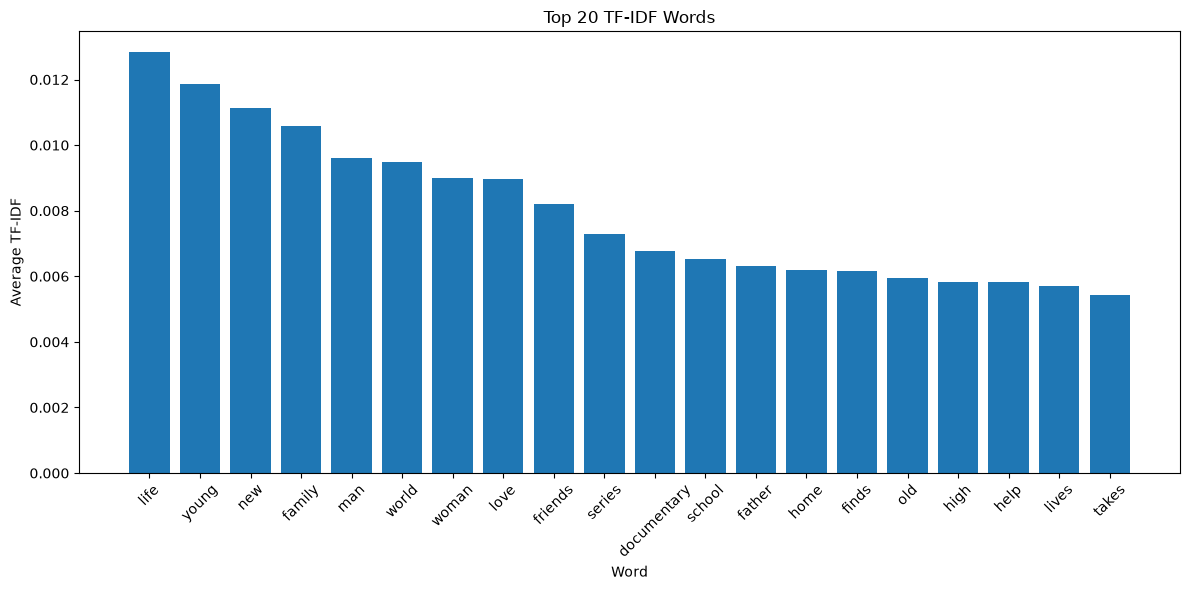

In [88]:
top20 = score.head(20)
plt.figure(figsize=(12,6))
plt.bar(top20.index, top20.values)
plt.xticks(rotation=45)
plt.xlabel("Word")
plt.ylabel("Average TF-IDF")
plt.title("Top 20 TF-IDF Words")
plt.tight_layout()
plt.show()

### 日本

In [89]:
jp = df[df["country"].str.contains("Japan", na=False)].dropna(subset=["description"])
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(jp["description"])
tfidf = pd.DataFrame(X.toarray(), columns = vectorizer.get_feature_names_out())
score = tfidf.mean().sort_values(ascending=False)
print(score.head(20))

young         0.019913
world         0.019336
school        0.015296
high          0.015215
life          0.014220
new           0.013020
mysterious    0.011731
evil          0.011675
years         0.010769
love          0.010333
girl          0.010298
friends       0.010269
group         0.009962
power         0.009932
battle        0.009798
lives         0.009500
demon         0.009359
schooler      0.008943
japan         0.008736
save          0.008688
dtype: float64


# レコメンドシステム

### 特徴量作成

In [90]:
df["features"] = df["listed_in"].fillna("")*3 + " " + df["director"].fillna("")*2 + " " + df["cast"].fillna("")*2 + " " + df["country"].fillna("") + " " + df["description"].fillna("")

### TF-IDF

In [91]:
tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2)
tfidf_matrix = tfidf.fit_transform(df["features"])

### 類似度計算

In [92]:
cosine_sim = cosine_similarity(tfidf_matrix)

### タイトルからおすすめ取得

In [93]:
indices = pd.Series(df.index, index=df["title"]).drop_duplicates()

def recommend(title, n=5):
    if title not in indices:
        return "作品が見つかりません。"
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]

    result = []
    for i, score in sim_scores:
        result.append({
            "Title": df.iloc[i]["title"],
            "Type": df.iloc[i]["type"],
            "Genre": df.iloc[i]["listed_in"],
            "Release Year": df.iloc[i]["release_year"]
        })
    return pd.DataFrame(result)

### おすすめ表示

In [95]:
recommend("Kota Factory")

,Title,Type,Genre,Release Year
0,Melodies of Life - Born This Way,TV Show,"International TV Shows, Romantic TV Shows, TV ...",2016
1,Find Yourself,TV Show,"International TV Shows, Romantic TV Shows, TV ...",2020
2,Dancing Angels,TV Show,"International TV Shows, Romantic TV Shows, TV ...",2016
3,I Need Romance,TV Show,"International TV Shows, Romantic TV Shows, TV ...",2021
4,Little Things,TV Show,"International TV Shows, Romantic TV Shows, TV ...",2019
